# 🌵 Predictive Water Resource Modeling
## Arid Grove Eco-Resort - Desert Water Demand
---
**Objective:** Build a regression model to forecast daily water demand (gallons/day)
to optimize water-hauling schedules and greywater recycling operations.

**Data Sources:**
- Hotel Booking Demand Dataset(Kaggle / Jesse Mostipak, CC0 Public Domain)
- Weather Data (Open-Meteo)

**Models Evaluated:** Elastic Net | Random Forest Regression | XGBoost

**Key Engineered Features** Peak Heat Days (≥95℉) | High-Density Booking Periods (>70% occ.)

# Imports & Configuration

In [1]:
# -- Imports -----------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                    'axes.spines.right': False, 'figure.dpi': 120})
# -- Resort Constants --------------------------------------------------------
RESORT_UNITS     = 40
MAX_GUESTS       = RESORT_UNITS * 2     # 2 guests per glamping unit
STORAGE_CAPACITY = 5_000                # Onsite emergency tank (gallons)
PEAK_HEAT_THRESH = 95                   # ℉ threshold for Peak Heat Day
HIGH_DENSITY_OCC = 0.70                 # Occupancy threshold for High-Density

# -- Brand Palette -----------------------------------------------------------
C = {
    'primary' : '#2E4057',
    'accent'  : '#048A81',
    'warm'    : '#E07A5F',
    'heat'    : '#E63946',
    'sand'    : '#F4A261',
    'light'   : '#F8F9FA',
}

print("✅ Libraries loaded")
print(f"  Resort: {RESORT_UNITS} units | {MAX_GUESTS} max guests | {STORAGE_CAPACITY:,} gal storage")

✅ Libraries loaded
  Resort: 40 units | 80 max guests | 5,000 gal storage


# Load Hotel Booking Dataset

In [2]:
import os

KAGGLE_PATH = '/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv'

if os.path.exists(KAGGLE_PATH):
    df_raw = pd.read_csv(KAGGLE_PATH)
    print("📂 Loaded from Kaggle environment")
else:
    # Public GitHub mirror of the Kaggle CC0 dataset (Jesse Mostipak)
    URL = (
        "https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
        "master/data/2020/2020-02-11/hotels.csv"
    )
    print(f"📥 Kaggle path not found – downloading from GitHub mirror...")
    df_raw = pd.read_csv(URL)
    print("✅ Download complete")

print(f"Raw shape          : {df_raw.shape}")
print(f"Columns            : {df_raw.columns.tolist()}")
print(f"\nHotel types      :\n{df_raw['hotel'].value_counts()}")
print(f"\nCancellation rate: {df_raw['is_canceled'].mean():.1%}")
df_raw.head(3)


📂 Loaded from Kaggle environment
Raw shape          : (119390, 32)
Columns            : ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Hotel types      :
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

Cancellation rate: 37.0%


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


# Filter,Parse Dates,Compute Guest Counts

In [3]:
df = df_raw[
    (df_raw['hotel']       == 'Resort Hotel') &
    (df_raw['is_canceled'] == 0) &
    (df_raw['adults']      >  0)
].copy()

# Parse arrival date
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

df['total_guests'] = (
    df['adults'] + df['children'].fillna(0) + df['babies'].fillna(0)
).astype(int).clip(lower=1)

df['stay_length'] = (
    df['stays_in_weekend_nights'] + df['stays_in_week_nights']
).clip(lower=1, upper=30).astype(int)

print(f"Filtered bookings : {len(df):,}")
print(f"Date range        : {df['arrival_date'].min().date()} → {df['arrival_date'].max().date()}")
print(f"Avg guests/booking: {df['total_guests'].mean():.2f}")
print(f"Avg stay length   : {df['stay_length'].mean():.2f} nights")

Filtered bookings : 28,927
Date range        : 2015-07-01 → 2017-08-31
Avg guests/booking: 1.95
Avg stay length   : 4.15 nights


# Expand Bookings to Daily Occupancy (Vectorized)

In [4]:
# -- Vectorized expansion -- each booking row becomes N date rows -----------------
arrivals = df['arrival_date'].values
stays    = df['stay_length'].values.astype(int)
guests_v = df['total_guests'].values

# Repeat each booking's data stay_length times, then add day offsets
rep_arrivals = np.repeat(arrivals, stays)
rep_guests   = np.repeat(guests_v, stays)
offsets      = np.concatenate([np.arange(s) for s in stays]).astype('timedelta64[D]')
actual_dates = rep_arrivals + offsets

daily_raw = pd.DataFrame({
    'date'  : pd.to_datetime(actual_dates),
    'guests': rep_guests.astype(int),
    'units' : 1
})

# Aggregate to daily level
daily_occ = daily_raw.groupby('date').agg(
    raw_guests = ('guests', 'sum'),
    raw_units  = ('units', 'sum')
).reset_index()

# -- Scale to 40-unit resort -------------------------------------------------------
# Use 95th percentile as "near full" to preserve natural variation
p95_units  = daily_occ['raw_units'].quantile(0.95)
p95_guests = daily_occ['raw_guests'].quantile(0.95)

daily_occ['units_occupied']     = (daily_occ['raw_units'] / p95_units * RESORT_UNITS).clip(1, RESORT_UNITS).round().astype(int)
daily_occ['guests_on_property'] = (daily_occ['raw_guests'] /p95_guests * MAX_GUESTS).clip(1, MAX_GUESTS).round().astype(int)
daily_occ['occupancy_rate']     = daily_occ['units_occupied'] / RESORT_UNITS

daily_occ = daily_occ.sort_values('date').reset_index(drop=True)

print(f"Daily records : {len(daily_occ):,}")
print(f"\nOccupancy summary:")
print(daily_occ[['units_occupied', 'guests_on_property', 'occupancy_rate']].describe().round(2))

Daily records : 806

Occupancy summary:
       units_occupied  guests_on_property  occupancy_rate
count          806.00              806.00          806.00
mean            32.38               56.29            0.81
std              9.42               19.22            0.24
min              1.00                1.00            0.02
25%             28.00               44.00            0.70
50%             37.00               63.00            0.92
75%             39.00               71.00            0.98
max             40.00               80.00            1.00


# WEATHER DATA FROM OPEN-METEO

In [5]:
import requests

# -- Resort Location -------------------------------------------------------------
# Fictional "Arid Grove" mapped to Sonoran Desert, Arizona
# Using Phoenix, AZ coordinates as the reference climate station
RESORT_LAT = 33.4484
RESORT_LON = -112.0740
TIMEZONE   = "America/Phoenix" #Arizona - no DST

# -- Determine date range from the occupancy data --------------------------------
start_date = daily_occ['date'].min().strftime('%Y-%m-%d')
end_date   = daily_occ['date'].max().strftime('%Y-%m-%d')

print(f"📡 Fetching Open-Meteo ERA5 historical weather data...")
print(f" Location   : Phoenix / Sonoran Desert ({RESORT_LAT}°N, {RESORT_LON}°W)")
print(f" Date range : {start_date} → {end_date}")

# -- PASS 1: Daily Variables (only confirmed valid names)
url_daily = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={RESORT_LAT}&longitude={RESORT_LON}"
    f"&start_date={start_date}&end_date={end_date}"
    f"&daily=temperature_2m_max,temperature_2m_min"
    f",apparent_temperature_max,apparent_temperature_min"
    f",shortwave_radiation_sum,et0_fao_evapotranspiration"
    f"&temperature_unit=fahrenheit"
    f"&timezone={TIMEZONE}"
)

r1 = requests.get(url_daily, timeout=60)
r1.raise_for_status()
d1 = r1.json()['daily']
print(f"✅ Pass 1 OK - daily temps, radiation, ET0")

# -- PASS 2: Hourly humidity → aggregate to daily mean ---------------------------
url_hourly = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={RESORT_LAT}&longitude={RESORT_LON}"
    f"&start_date={start_date}&end_date={end_date}"
    f"&hourly=relative_humidity_2m"
    f"&timezone={TIMEZONE}"
)

r2 = requests.get(url_hourly, timeout=60)
r2.raise_for_status()
d2 = r2.json() ['hourly']
print(f"✅ Pass 2 OK - hourly humidity fetched")

# Aggregate hourly humidity to daily
humidity_hourly = pd.DataFrame({
    'datetime': pd.to_datetime(d2['time']),
    'rh'      : d2['relative_humidity_2m']
})
humidity_hourly['date']       = humidity_hourly['datetime'].dt.normalize()  # floor to day
humidity_daily                = humidity_hourly.groupby('date')['rh'].mean().reset_index()
humidity_daily.columns        = ['date', 'humidity_pct']
humidity_daily['date']        = pd.to_datetime(humidity_daily['date'])
humidity_daily['humidity_pct'] = humidity_daily['humidity_pct'].round(1)

# -- Parse into DataFrame --------------------------------------------------------
weather_df = pd.DataFrame({
    'date'             : pd.to_datetime(d1['time']),
    'temp_f'           : d1['temperature_2m_max'],          # Daily high ℉
    'temp_min_f'       : d1['temperature_2m_min'],          # Daily low ℉
    'apparent_max'     : d1['apparent_temperature_max'],
    'apparent_min'     : d1['apparent_temperature_min'],
    'shortwave_rad'    : d1['shortwave_radiation_sum'],     # MJ/m²/day
    'et0'              : d1['et0_fao_evapotranspiration'],  # mm/day
})

humidity_daily['date'] = pd.to_datetime(humidity_daily['date'])
weather_df['date']     = pd.to_datetime(weather_df['date'])
weather_df = weather_df.merge(humidity_daily, on='date', how='left')

# -- Derive UV Index from shortwave radiation -------------------------------------
# Approximation: UV Index ≈ shortwave_sum(MJ/m²) x 0.40
# Phoenix summer: ⁓28 MJ/m² → UV ⁓11.2 ✓ Winter: ⁓12 MJ/m² → UV ⁓4.8 ✓
weather_df['uv_index'] = (
    weather_df['shortwave_rad'].fillna(0) * 0.40
).clip(1, 13).round(1)

# -- Interpolate any gaps
for col in ['temp_f','temp_min_f','humidity_pct','uv_index','et0']:
    weather_df[col] = weather_df[col].interpolate(method='linear').round(1)

weather_df = weather_df.sort_values('date').reset_index(drop=True)


print(f"\n Records fetched : {len(weather_df):,} days")
print(weather_df[['temp_f','humidity_pct','uv_index','et0',]].describe().round(2))
print(f"\n Hottest day     : {weather_df['temp_f'].max():.1f}℉ on {weather_df.loc[weather_df['temp_f'].idxmax(), 'date'].date()}")
print(f" Coolest day       : {weather_df['temp_f'].min():.1f}℉ on {weather_df.loc[weather_df['temp_f'].idxmin(), 'date'].date()}")
print(f" Driest avg RH     : {weather_df['humidity_pct'].min():.1f}%")

📡 Fetching Open-Meteo ERA5 historical weather data...
 Location   : Phoenix / Sonoran Desert (33.4484°N, -112.074°W)
 Date range : 2015-07-01 → 2017-09-13
✅ Pass 1 OK - daily temps, radiation, ET0
✅ Pass 2 OK - hourly humidity fetched

 Records fetched : 806 days
       temp_f  humidity_pct  uv_index     et0
count  806.00        806.00    806.00  806.00
mean    87.97         36.42      8.40    5.64
std     16.19         18.81      2.78    2.57
min     52.90          6.10      1.00    0.70
25%     75.03         21.20      6.10    3.40
50%     90.70         32.30      8.70    5.80
75%    101.70         50.58     10.80    7.70
max    117.80         91.70     13.00   12.00

 Hottest day     : 117.8℉ on 2016-06-19
 Coolest day       : 52.9℉ on 2016-12-25
 Driest avg RH     : 6.1%


# Merge & Generate Water Demand Target Variable

In [6]:
df_merged = daily_occ.merge(weather_df, on='date', how='inner')

def compute_water_demand(guests, units, temp, humidity):
    """
    Physics-based water demand model for a 40-unit luxury glamping resort.

    Components:
        Personal use      - 50 gal/guest/day (shower, toilet, drinking, cooking)
        Communal pool     - base evaporation + temperature scaling + bather load
        Misting systems   - activates at 88℉, non-linear above threshold
        Landscaping       - desert-adapted but resort maintains grass/garden areas
        Kitchen/common    - 22 gal per occupied unit (staff, laundry, common areas)
    """
    personal    = 50 * guests
    pool        = 200 + max(0, (temp - 80) * 3) + guests * 1.5
    misting     = max(0, (temp - 88) ** 1.4 * 8) if temp > 88 else 0
    landscaping = 260 + max(0, (temp - 75) * 4.2) + max(0, (30 - humidity) * 5.5)
    kitchen     = 22 * units
    return personal + pool + misting + landscaping + kitchen

# Vectorized apply
df_merged['water_demand_base'] = [
    compute_water_demand(r.guests_on_property, r.units_occupied, r.temp_f, r.humidity_pct)
    for r in df_merged.itertuples()
]

# Add ±8% operational noise (equipment variation, data logging error)
noise = np.random.normal(1.0, 0.08, len(df_merged))
df_merged['water_demand_gal'] = (df_merged['water_demand_base'] * noise).round().astype(int).clip(lower=500)

print("Water demand target generated:")
print(df_merged['water_demand_gal'].describe().apply(lambda x: f'{x:,.0f}'))
print(f"\n Min: {df_merged['water_demand_gal'].min():,} gal")
print(f" Max  : {df_merged['water_demand_gal'].max():,} gal")
print(f" Mean : {df_merged['water_demand_gal'].mean():,.0f} gal")

Water demand target generated:
count      806
mean     4,356
std      1,433
min        809
25%      3,312
50%      4,610
75%      5,446
max      7,249
Name: water_demand_gal, dtype: object

 Min: 809 gal
 Max  : 7,249 gal
 Mean : 4,356 gal


# EDA Overview Dashboard

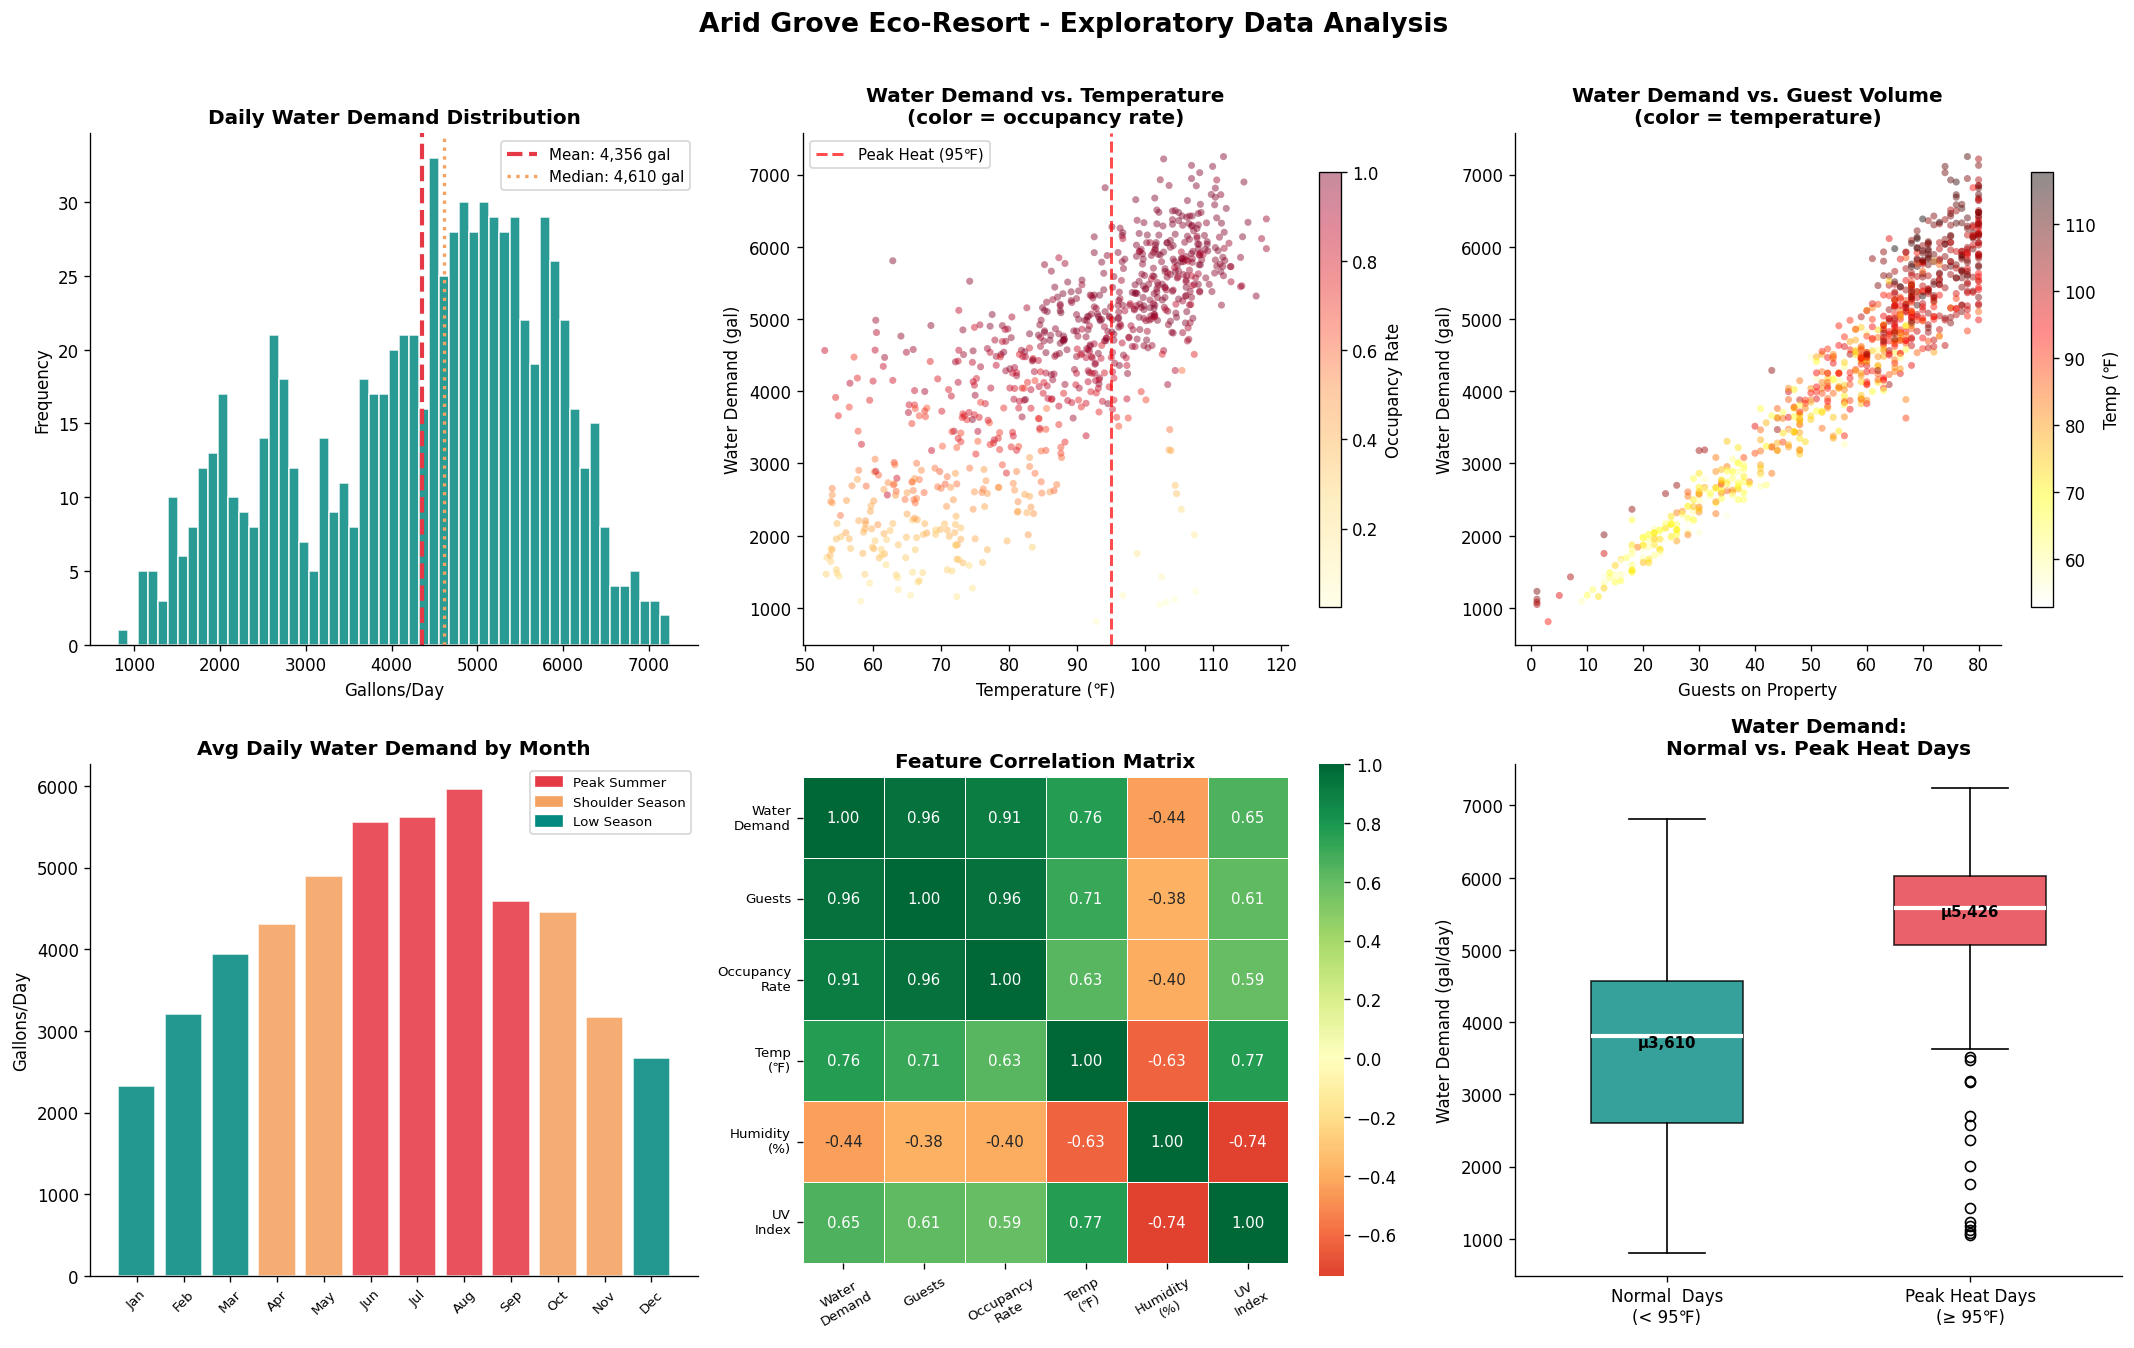


📊 KEY CORRELATION FINDINGS:
 Water Demand ↔temp_f                 r = +0.7642
 Water Demand ↔guests_on_property     r = +0.9552
 Water Demand ↔occupancy_rate         r = +0.9083
 Water Demand ↔humidity_pct           r = -0.4395


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Arid Grove Eco-Resort - Exploratory Data Analysis',
            fontsize=16, fontweight='bold', y=1.01)

# -- 1. Water Demand Distribution ------------------------------------------------------------------------------------
ax = axes[0, 0]
ax.hist(df_merged['water_demand_gal'], bins=55, color=C['accent'], edgecolor='white', alpha=0.85)
ax.axvline(df_merged['water_demand_gal'].mean(), color=C['heat'], lw=2.5, linestyle='--',
          label=f"Mean: {df_merged['water_demand_gal'].mean():,.0f} gal")
ax.axvline(df_merged['water_demand_gal'].median(), color=C['sand'], lw=2, linestyle=':',
          label=f"Median: {df_merged['water_demand_gal'].median():,.0f} gal")
ax.set_title('Daily Water Demand Distribution', fontweight='bold')
ax.set_xlabel('Gallons/Day'); ax.set_ylabel('Frequency')
ax.legend(fontsize=9)

# -- 2. Water Demand vs Temperature -----------------------------------------------------------------------------------
ax = axes[0, 1]
sc = ax.scatter(df_merged['temp_f'], df_merged['water_demand_gal'],
               c=df_merged['occupancy_rate'], cmap='YlOrRd',
               alpha=0.45, s=18, edgecolors='none')
plt.colorbar(sc, ax=ax, label= 'Occupancy Rate', shrink=0.85)
ax.axvline(PEAK_HEAT_THRESH, color='red', lw=1.8, linestyle='--', alpha=0.7, label=f'Peak Heat ({PEAK_HEAT_THRESH}℉)')
ax.set_title('Water Demand vs. Temperature\n(color = occupancy rate)', fontweight='bold')
ax.set_xlabel('Temperature (℉)'); ax.set_ylabel('Water Demand (gal)')
ax.legend(fontsize=9)

# -- 3. Water Demand vs Guest Volume ----------------------------------------------------------------------------------
ax = axes[0, 2]
sc2 = ax.scatter(df_merged['guests_on_property'], df_merged['water_demand_gal'],
                c=df_merged['temp_f'], cmap='hot_r', alpha=0.45, s=18, edgecolors='none')
plt.colorbar(sc2, ax=ax, label='Temp (℉)', shrink=0.85)
ax.set_title('Water Demand vs. Guest Volume\n(color = temperature)', fontweight='bold')
ax.set_xlabel('Guests on Property'); ax.set_ylabel('Water Demand (gal)')

# -- 4. Monthly Average Demand
ax = axes[1, 0]
monthly_avg = df_merged.groupby(df_merged['date'].dt.month)['water_demand_gal'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors = [C['heat'] if m in [6,7,8,9] else
             C['sand'] if m in [4,5,10,11] else C['accent'] for m in range(1,13)]
ax.bar(range(1,13), monthly_avg.values, color=bar_colors, alpha=0.88, edgecolor='white')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
ax.set_title('Avg Daily Water Demand by Month', fontweight='bold')
ax.set_ylabel('Gallons/Day')
legend_elems = [mpatches.Patch(color=C['heat'], label='Peak Summer'),
               mpatches.Patch(color=C['sand'], label='Shoulder Season'),
               mpatches.Patch(color=C['accent'], label='Low Season')]
ax.legend(handles=legend_elems, fontsize=8)

# -- 5. Correlation Heatmap ---------------------------------------------------------------------------------------------
ax = axes[1, 1]
corr_cols = ['water_demand_gal','guests_on_property','occupancy_rate',
            'temp_f','humidity_pct', 'uv_index']
corr_labels = ['Water\nDemand','Guests','Occupancy\nRate','Temp\n(℉)','Humidity\n(%)','UV\nIndex']
corr_matrix = df_merged[corr_cols].corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
           center=0, square=True, annot_kws={'size':9},
           xticklabels=corr_labels, yticklabels=corr_labels,
           linewidths=0.5, linecolor='white')
ax.set_title('Feature Correlation Matrix', fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

# -- 6. Peak Heat vs Normal Day Boxplot ----------------------------------------------------------------------------------
ax = axes[1, 2]
peak_heat_flag = df_merged['temp_f'] >= PEAK_HEAT_THRESH
groups = [
    df_merged[~peak_heat_flag]['water_demand_gal'].values,
    df_merged[peak_heat_flag]['water_demand_gal'].values
]
bp = ax.boxplot(groups, labels=['Normal  Days\n(< 95℉)', 'Peak Heat Days\n(≥ 95℉)'],
               patch_artist=True, widths=0.5,
               medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set(facecolor=C['accent'], alpha=0.8)
bp['boxes'][1].set(facecolor=C['heat'], alpha=0.8)
ax.set_title('Water Demand:\nNormal vs. Peak Heat Days', fontweight='bold')
ax.set_ylabel('Water Demand (gal/day)')

# Add mean annotations
for i, g in enumerate(groups, 1):
    ax.text(i, np.mean(g),  f'µ{np.mean(g):,.0f}', ha='center', va='bottom',
           fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Print Key Correlations ------------------------------------------------------------------------------------------------
print("\n📊 KEY CORRELATION FINDINGS:")
for col in ['temp_f', 'guests_on_property', 'occupancy_rate', 'humidity_pct']:
    r = df_merged['water_demand_gal'].corr(df_merged[col])
    print(f" Water Demand ↔{col:<22} r = {r:+.4f}")

# Feature Engineering

# **Build All Features**

In [8]:
df_feat = df_merged.copy().sort_values('date').reset_index(drop=True)

# -- Temporal Features ----------------------------------------------------------------------------
df_feat['month']             = df_feat['date'].dt.month
df_feat['day_of_week']       = df_feat['date'].dt.dayofweek
df_feat['week_of_year']      = df_feat['date'].dt.isocalendar().week.astype(int)
df_feat['is_weekend']        = (df_feat ['day_of_week'] >= 5).astype(int)
df_feat['quarter']           = df_feat['date'].dt.quarter
df_feat['is_summer']         = df_feat['month'].isin([6,7,8]).astype(int)
df_feat['peak_season']       = df_feat['month'].isin([7,8,9]).astype(int)

# =================================================================================================
# KEY ENGINEERED FEATURE 1: Peak Heat Day
# Definition: Daily high temperature  >= 95℉
# Operational significance: Triggers misting systems,pool cooling, increased
#  guest hydration demand, and potential greywater recycling activation.
# =================================================================================================
df_feat['peak_heat_day'] = (df_feat['temp_f'] >= 95).astype(int)

# =================================================================================================
# KEY ENGINEERED FEATURE 2: High-Density Booking Period
# Definition: Occupancy rate > 70% (>28 of 40 units occupied)
# Operational significance: Communal areas at stress load - shared pool, dining,
#  showers, laundry - drives non-linear demand spikes.
# ==================================================================================================
df_feat['high_density'] = (df_feat['occupancy_rate'] > HIGH_DENSITY_OCC).astype(int)

# -- Additional Engineered Features ----------------------------------------------------------------
# Extreme heat flag
df_feat['extreme_heat_day'] = (df_feat['temp_f'] >= 105).astype(int)

#NOAA Heat Index
T = df_feat['temp_f']
H = df_feat['humidity_pct']
df_feat['heat_index'] = (
    -42.379 + 2.04901523*T + 10.14333127*H
    - 0.22475541*T*H - 0.00683783*T**2 - 0.05481717*H**2
    + 0.00122874*T**2*H +  0.00085282*T*H**2 - 0.00000199*T**2*H**2    
).clip(lower=df_feat['temp_f'])

# Interaction: heat x occupancy stress
df_feat['heat_x_occupancy'] = df_feat['temp_f'] * df_feat['occupancy_rate']

# Misting demand proxy (non-linear above 88℉ activation)
df_feat['misting_proxy'] = np.where(df_feat['temp_f'] > 88,
                                    (df_feat['temp_f'] - 88) ** 1.4, 0)

# Aridity Index (high temp + low humidity = maximum evaporative stress)
df_feat['aridity_index'] = df_feat['temp_f'] / (df_feat['humidity_pct'] + 1)

# 3-day rolling temperature average (heat wave carry-over)
df_feat['temp_rolling_3d'] = df_feat['temp_f'].rolling(window=3, min_periods=1).mean()

#Guest density per occupied  unit
df_feat['guests_per_unit'] =df_feat['guests_on_property'] / df_feat['units_occupied'].clip(lower=1)

# -- Feature Columns -------------------------------------------------------------------------------
FEATURE_COLS = [
    # Occupancy
    'guests_on_property', 'units_occupied', 'occupancy_rate', 'guests_per_unit',
    # Weather (real ERA5 data via Open-Meteo)
    'temp_f', 'humidity_pct', 'uv_index', 'heat_index', 'et0',
    # Engineered - Peak Heat & High-Density
    'peak_heat_day', 'extreme_heat_day', 'high_density',
    # Engineered - Derived Signals
    'heat_x_occupancy', 'misting_proxy', 'aridity_index', 'temp_rolling_3d',
    # Temporal
    'month', 'day_of_week', 'is_weekend', 'quarter', 'is_summer', 'peak_season'
]

# -- Feature Summary -------------------------------------------------------------------------------
print("✅ Feature engineering complete\n")
print(f" Peak Heat Days     : {df_feat['peak_heat_day'].sum():>5,}  ({df_feat['peak_heat_day'].mean()*100:.1f}% of all days)")
print(f" High-Density Days  : {df_feat['high_density'].sum():>5,}  ({df_feat['high_density'].mean()*100:.1f}% of all days)")
print(f" Extreme Heat Days  : {df_feat['extreme_heat_day'].sum():>5,} ({df_feat['extreme_heat_day'].mean()*100:.1f}% of all days)")
print(f" Total features     : {len(FEATURE_COLS)}")

peak_mean = df_feat[df_feat['peak_heat_day']==1]['water_demand_gal'].mean()
normal_mean = df_feat[df_feat['peak_heat_day']==0]['water_demand_gal'].mean()
hd_mean = df_feat[df_feat['high_density']==1]['water_demand_gal'].mean()
print(f"\n Peak Heat Day avg demand :{peak_mean:,.0f} gal (+{(peak_mean/normal_mean-1)*100:.1f}% vs normal)")
print(f" High-Density Day avg demand: {hd_mean:,.0f} gal")

✅ Feature engineering complete

 Peak Heat Days     :   331  (41.1% of all days)
 High-Density Days  :   593  (73.6% of all days)
 Extreme Heat Days  :   130 (16.1% of all days)
 Total features     : 22

 Peak Heat Day avg demand :5,426 gal (+50.3% vs normal)
 High-Density Day avg demand: 5,053 gal


# Modeling

# **Prepare Train/Test Split**

In [9]:
FEATURE_COLS = [
    # Occupancy
    'guests_on_property', 'units_occupied', 'occupancy_rate', 'guests_per_unit',
    # Weather (real ERA5 data via Open-Meteo)
    'temp_f', 'humidity_pct', 'uv_index', 'heat_index', 'et0',
    # Engineered - Peak Heat & High-Density
    'peak_heat_day', 'extreme_heat_day', 'high_density',
    # Engineered - Derived Signals
    'heat_x_occupancy', 'misting_proxy', 'aridity_index', 'temp_rolling_3d',
    # Temporal
    'month', 'day_of_week', 'is_weekend', 'quarter', 'is_summer', 'peak_season'
]

TARGET_COL = 'water_demand_gal'

X = df_feat[FEATURE_COLS].copy()
y = df_feat[TARGET_COL].copy()

# Time-ordered split (no data leakage - traain on past, test on future)
split_idx = int(len(df_feat) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training samples : {len(X_train):,} ({len(X_train)/len(X)*100:0f}%)")
print(f"Test samples     : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)")
print(f"Features         : {len(FEATURE_COLS)}")
print(f"\nTarget range   : {y.min():,} - {y.max():,} gallons")
print(f"Target mean      : {y.mean():,.0f} gallons")
print(f"Target std       : {y.std():,.0f} gallons")

Training samples : 644 (79.900744%)
Test samples     : 162 (20%)
Features         : 22

Target range   : 809 - 7,249 gallons
Target mean      : 4,356 gallons
Target std       : 1,433 gallons


# Define, Train & Evaluate All Three Models

In [10]:
models = {
    'Elastic Net': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(
            alpha        = 10.0,
            l1_ratio     = 0.5,
            max_iter     = 20_000,
            random_state = 42
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(
        n_estimators     = 300,
        max_depth        = 14,
        min_samples_leaf = 4,
        max_features     = 'sqrt',
        n_jobs           = -1,
        random_state     = 42
        ))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', xgb.XGBRegressor(
            n_estimators     = 400,
            max_depth        = 6,
            learning_rate    = 0.04,
            subsample        = 0.80,
            colsample_bytree = 0.80,
            reg_alpha        = 0.5,
            reg_lambda       = 1.5,
            random_state     = 42,
            verbosity        = 0
        ))
    ])
}

results      = {}
predictions  = {}
cv_scores    = {}

print(f"{'='*58}")
print(f" MODEL EVALUAATION RESULTS")
print(f"{'='*58}")

kf = KFold(n_splits=5, shuffle=False)  # time-order CV

for name, pipeline in models.items():
     # Train
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred

    # Metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

    # Cross-validation on full dataset
    cv_r2 = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')
    cv_scores[name] = cv_r2

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape,
                'CV R² Mean': cv_r2.mean(), 'CV R² Std': cv_r2.std()}

    print(f"\n {'⭐ ' if r2 == max(v['R²'] for v in results.values()) else '  '}{name}")
    print(f" ⊢MAE   : {mae:>8,.1f} gal")
    print(f" ⊢RMSE  : {rmse:>8,.1f} gal")
    print(f" ⊢R²    : {r2:>8.4f}")
    print(f" ⊢MAPE  : {mape:>8.2f}%")
    print(f" ⨽CV R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

results_df = pd.DataFrame(results).T
BEST_MODEL = results_df['R²'].idxmax()
print(f"\n{'='*58}")
print(f" ✅ Best model: {BEST_MODEL}")
print(f" R² = {results_df.loc[BEST_MODEL, 'R²']:.4f} | MAPE = {results_df.loc[BEST_MODEL, 'MAPE']:.2f}%")

 MODEL EVALUAATION RESULTS

 ⭐ Elastic Net
 ⊢MAE   :    605.2 gal
 ⊢RMSE  :    784.7 gal
 ⊢R²    :   0.5965
 ⊢MAPE  :    18.19%
 ⨽CV R² : 0.5421 ± 0.2445

 ⭐ Random Forest
 ⊢MAE   :    394.1 gal
 ⊢RMSE  :    509.6 gal
 ⊢R²    :   0.8299
 ⊢MAPE  :    11.54%
 ⨽CV R² : 0.8317 ± 0.1296

 ⭐ XGBoost
 ⊢MAE   :    384.0 gal
 ⊢RMSE  :    495.5 gal
 ⊢R²    :   0.8391
 ⊢MAPE  :     9.27%
 ⨽CV R² : 0.8184 ± 0.1474

 ✅ Best model: XGBoost
 R² = 0.8391 | MAPE = 9.27%


# Model Performance Visualization

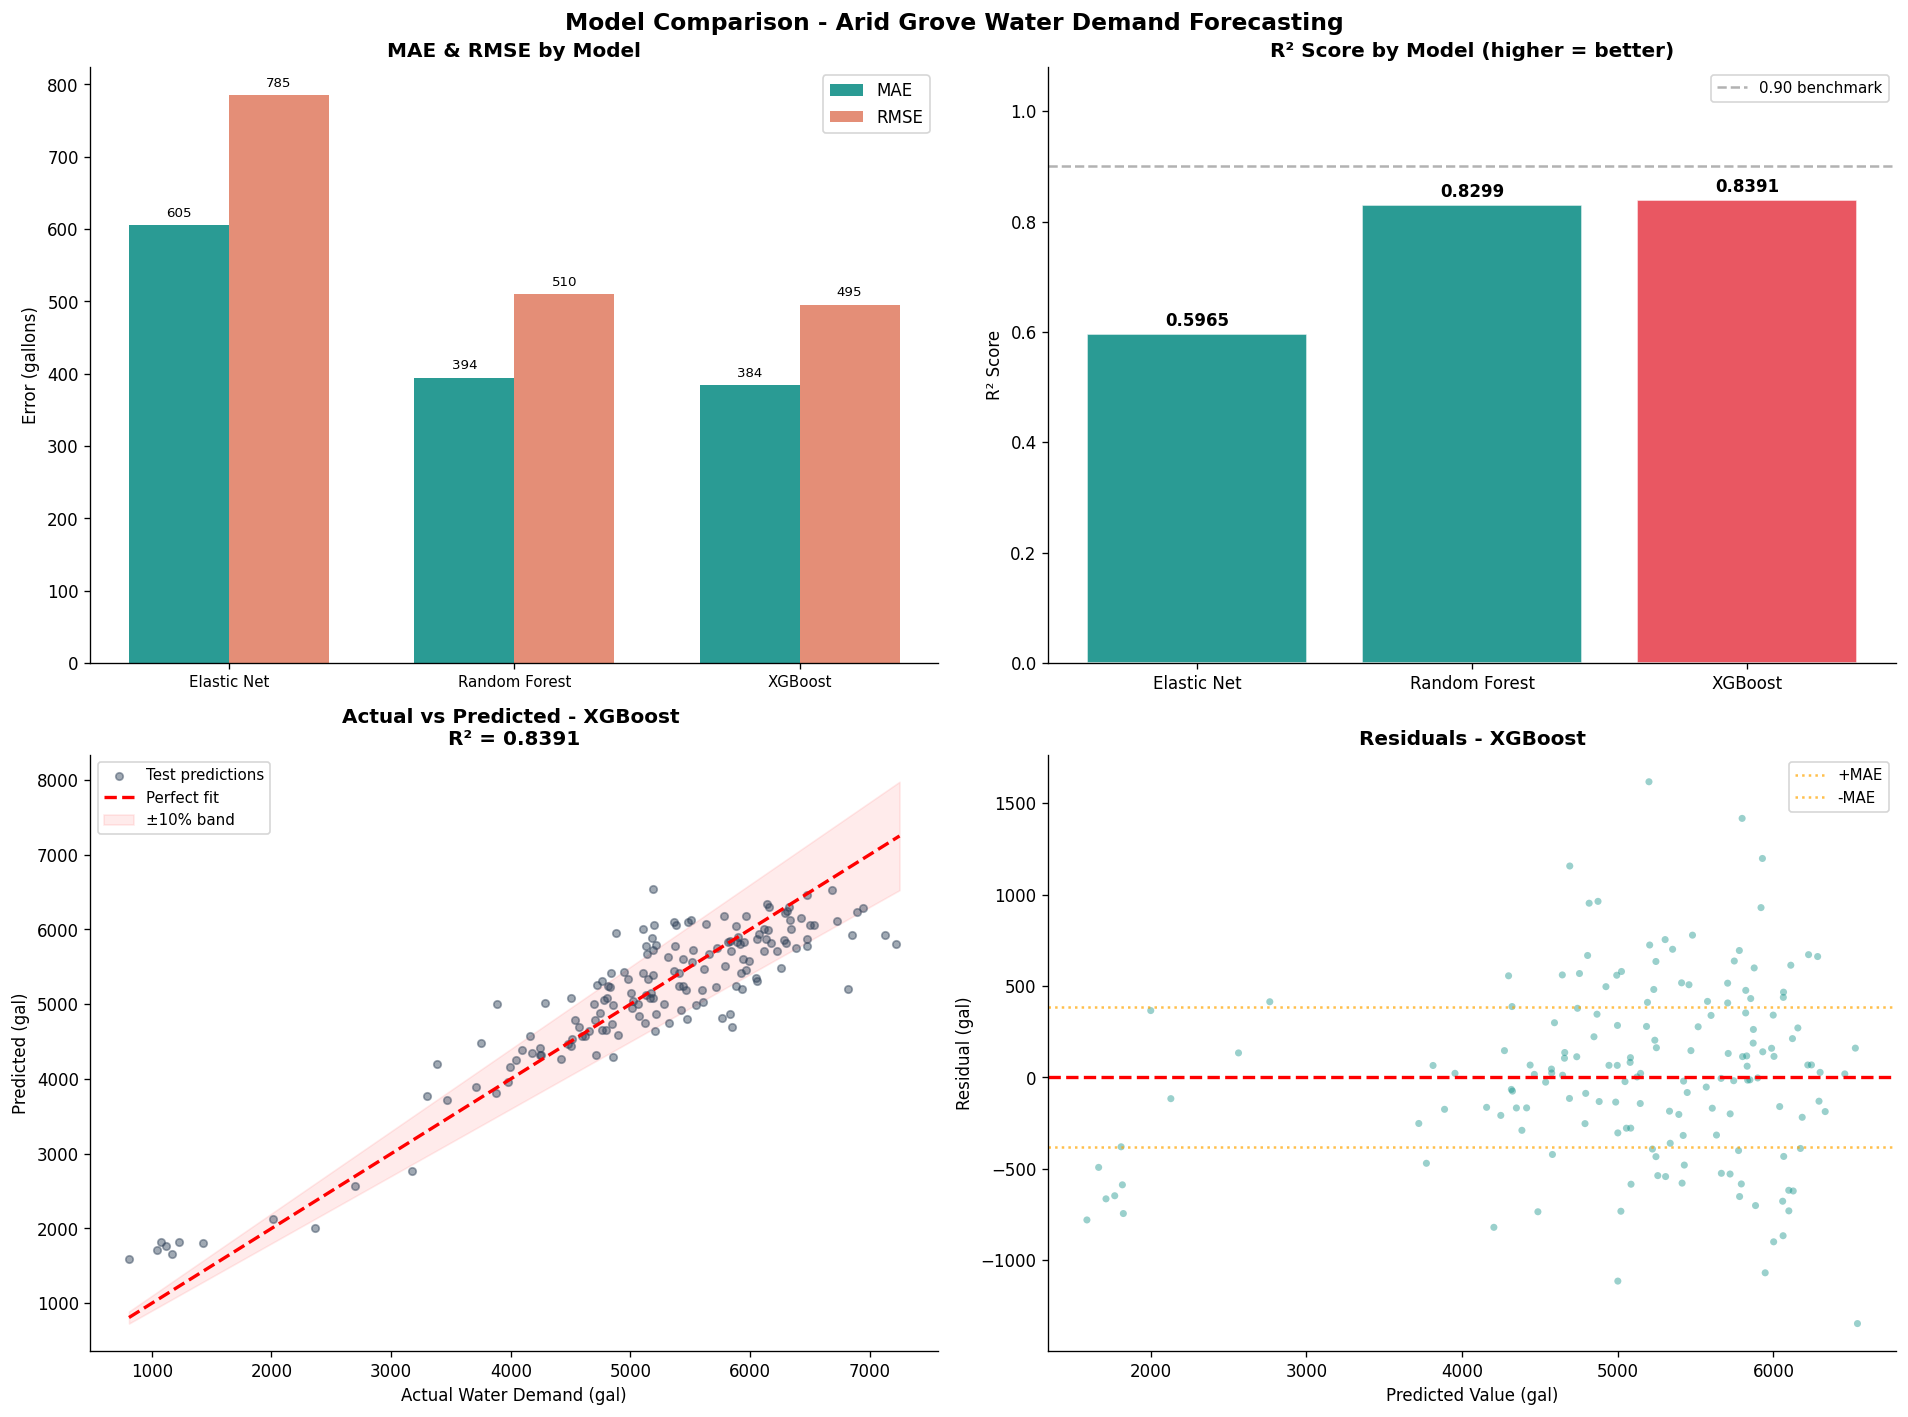

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Model Comparison - Arid Grove Water Demand Forecasting',
            fontsize=14, fontweight='bold')

model_names = list(results.keys())
bar_colors  = [C['heat'] if m == BEST_MODEL else C['accent'] for m in model_names]

# -- 1. MAE & RMSE bar chart ---------------------------------
ax = axes[0, 0]
x  = np.arange(len(model_names))
w  = 0.35
b1 = ax.bar(x - w/2, [results[m]['MAE'] for m in model_names], w, label='MAE', color=C['accent'], alpha=0.85)
b2 = ax.bar(x + w/2, [results[m]['RMSE'] for m in model_names], w, label='RMSE', color=C['warm'], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylabel('Error (gallons)'); ax.set_title('MAE & RMSE by Model', fontweight='bold')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
           f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

# -- 2. R² comparison -----------------------------------------------------------
ax      = axes[0,1]
r2_vals = [results[m]['R²'] for m in model_names]
bars    = ax.bar(model_names, r2_vals, color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_ylim(0, 1.08); ax.set_ylabel('R² Score')
ax.set_title('R² Score by Model (higher = better)', fontweight='bold')
ax.axhline(0.90, color='gray', lw=1.5, linestyle='--', alpha=0.6, label='0.90 benchmark')
ax.legend(fontsize=9)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.008,
           f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# -- 3. Predicted vs Actual -- Best Model -----------------------------------------
ax = axes [1, 0]
y_pred_best = predictions[BEST_MODEL]
ax.scatter(y_test.values, y_pred_best, alpha=0.45, s=20,
          color=C['primary'], label='Test predictions', zorder=2)
lims = [min(y.min(), y_pred_best.min()), max(y.max(), y_pred_best.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit', zorder=3)
ax.fill_between(lims, [l*0.90 for l in lims], [l*1.10 for l in lims],
               alpha=0.08, color='red', label='±10% band')
ax.set_xlabel('Actual Water Demand (gal)'); ax.set_ylabel('Predicted (gal)')
ax.set_title(f'Actual vs Predicted - {BEST_MODEL} \nR² = {results[BEST_MODEL]["R²"]:.4f}',
            fontweight='bold')
ax.legend(fontsize=9)

# -- 4. Feature Importance ---------------------------------------------------------
ax = axes[1, 1]
residuals = y_test.values - y_pred_best
ax.scatter(y_pred_best, residuals, alpha=0.4, s=18, color=C['accent'], edgecolors='none')
ax.axhline(0, color='red', lw=2, linestyle='--')
ax.axhline(+results[BEST_MODEL]['MAE'], color='orange', lw=1.5, linestyle=':', alpha=0.7, label='+MAE')
ax.axhline(-results[BEST_MODEL]['MAE'], color='orange', lw=1.5, linestyle=':', alpha=0.7, label='-MAE')
ax.set_xlabel('Predicted Value (gal)'); ax.set_ylabel('Residual (gal)')
ax.set_title(f'Residuals - {BEST_MODEL}', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance

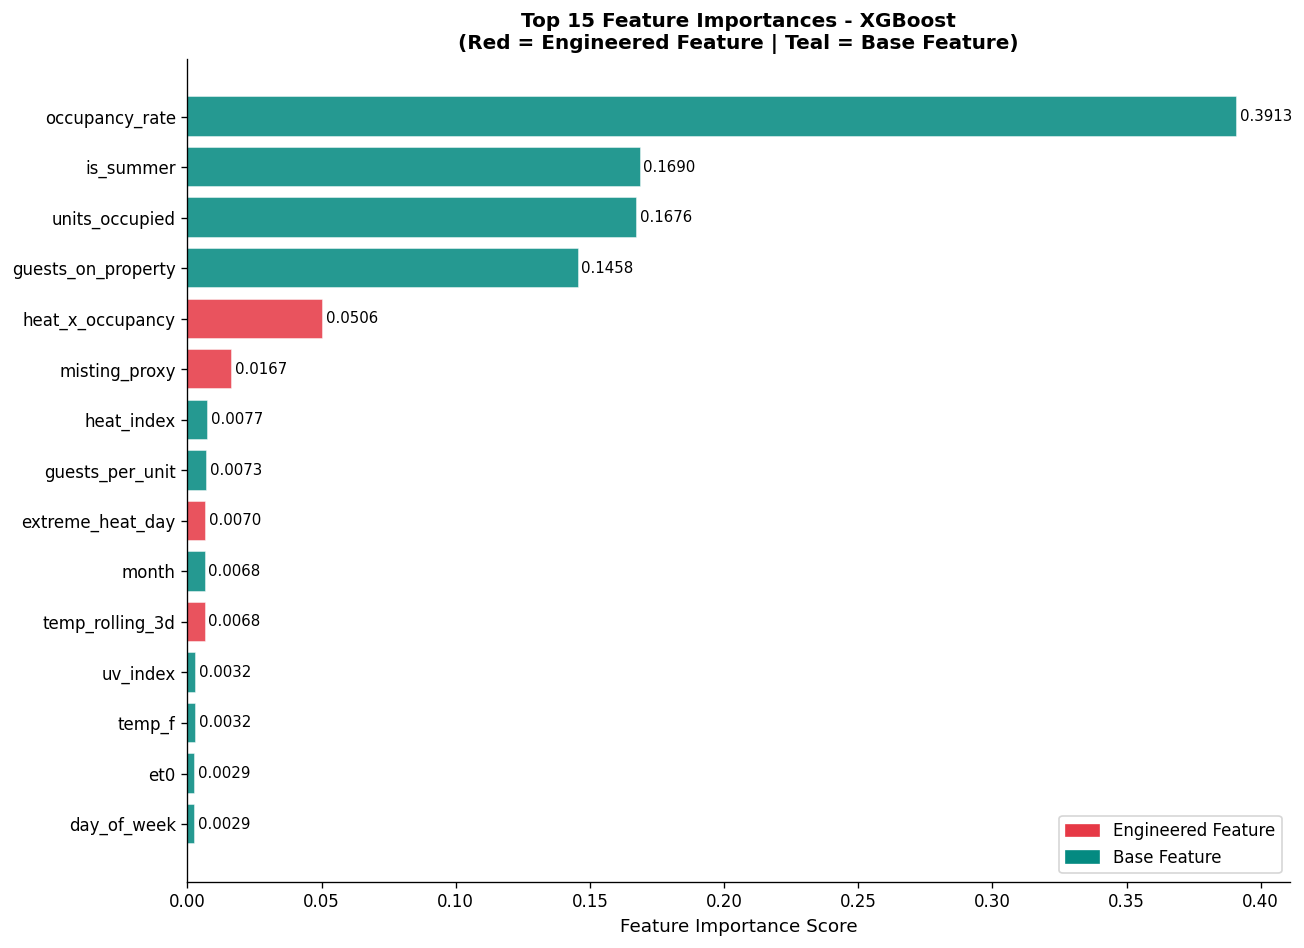


📊 TOP 5 MOST IMPORTANT FEATURES:
 📈 occupancy_rate                 0.3913
 📈 is_summer                      0.1690
 📈 units_occupied                 0.1676
 📈 guests_on_property             0.1458
 🔧 heat_x_occupancy               0.0506


In [12]:
best_pipeline  = models[BEST_MODEL]
best_estimator = best_pipeline.named_steps['model']

fig, ax = plt.subplots(figsize=(11, 8))

if hasattr(best_estimator, 'feature_importances_'):
    importances = best_estimator.feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})\
                    .sort_values('Importance', ascending=False).head(15)

    ENGINEERED = {'peak_heat_day','high_density','extreme_heat_day',
                 'heat_x_occupancy','misting_proxy','aridity_index','temp_rolling_3d'}
    bar_colors_fi = [C['heat'] if f in ENGINEERED else C['accent'] for f in feat_imp_df['Feature']]

    bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
                  color=bar_colors_fi, alpha=0.87, edgecolor='white')
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance Score', fontsize=11)
    ax.set_title(f'Top 15 Feature Importances - {BEST_MODEL}\n'
                 f'(Red = Engineered Feature | Teal = Base Feature)',
                 fontweight='bold', fontsize=12)
    for bar, val in zip(bars, feat_imp_df['Importance']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
               f'{val:.4f}', va='center', fontsize=9)

    legend_elems = [mpatches.Patch(color=C['heat'], label='Engineered Feature'),
                    mpatches.Patch(color=C['accent'],label='Base Feature')]
    ax. legend(handles=legend_elems, fontsize=10)

elif hasattr(best_estimator, 'coef_'): # Elastic Net fallback
    coefs = np.abs(best_estimator.coef_)
    feat_imp_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': coefs})\
                    .sort_values('Importance', ascending=False).head(15)
    ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=C['accent'], alpha=0.85)
    ax.invert_yaxis()
    ax.set_xlabel('|Coefficient|')
    ax.set_title(f'Feature Coefficients - {BEST_MODEL}', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 TOP 5 MOST IMPORTANT FEATURES:")
for i, row in feat_imp_df.head(5).iterrows():
    marker = "🔧" if row ['Feature'] in ENGINEERED else "📈"
    print(f" {marker} {row['Feature']:<30} {row['Importance']:.4f}")

# Drought Scenario Stress Test

# **Build the Drought Simulation**

In [13]:
print("=" * 62)
print(" 🌵 DROUGHT SCENARIO STRESS TEST")
print(" Simulating a 14-day compounding extreme heat event")
print(" All amenities (pool, misting, irrigation) at maximum")
print("=" * 62)

DROUGHT_PHASES = [
    ('Days 1-3\n(Moderate)', 3, {'temp_f': 105, 'humidity_pct': 12, 'occupancy_rate': 0.85}),
    ('Days 4-7\n(Severe)', 4, {'temp_f': 110, 'humidity_pct': 8, 'occupancy_rate': 0.90}),
    ('Days 8-10\n(Extreme)', 3, {'temp_f': 113, 'humidity_pct': 6, 'occupancy_rate': 0.95}),
    ('Days 11-14\n(Crisis)', 4, {'temp_f': 116, 'humidity_pct': 5, 'occupancy_rate': 1.00}),
]

# Compute baseline demand for comparison
baseline_input = {
    'guests_on_property': 58, 'units_occupied': 29, 'occupancy_rate': 0.725,
    'temp_f': 95, 'humidity_pct': 18, 'uv_index': 10, 'et0': 8.5,
    'heat_index': 96, 'peak_heat_day':1, 'extreme_heat_day': 0, 'high_density': 0,
    'heat_x_occupancy': 95 * 0.725, 'misting_proxy': (95-88)**1.4,
    'aridity_index': 95/19, 'temp_rolling_3d': 93, 'guests_per_unit': 2.0,
    'month': 8, 'day_of_week': 2, 'is_weekend': 0, 'quarter': 3, 'is_summer': 1, 'peak_season':  1
}
BASELINE_DEMAND = best_pipeline.predict(pd.DataFrame([baseline_input])[FEATURE_COLS])[0]

# Build drought day records
drought_records = []
day_num = 1

for phase_label, duration, params in DROUGHT_PHASES:
    t = params['temp_f']
    h = params['humidity_pct']
    occ = params['occupancy_rate']
    guests = int(occ * MAX_GUESTS)
    units  = int(occ * RESORT_UNITS)

    heat_idx = max(t, -42.379 + 2.049*t + 10.143*h - 0.225*t*h
                  - 0.00684*t**2 - 0.0548*h**2 + 0.00123*t**2*h
                  + 0.000853*t*h**2 - 0.000002*t**2*h**2)

    for d in range(duration):
        drought_records.append({
            'day'                : day_num,
            'phase'              : phase_label,
            'guests_on_property' : guests,
            'units_occupied'     : units,
            'occupancy_rate'     : occ,
            'temp_f'             : round(t + np.random.normal(0, 0.8), 1),
            'humidity_pct'       : h,
            'uv_index'           : 12.5,
            'et0'                : round(12.0 + (t - 105) * 0.3, 1),
            'heat_index'         : heat_idx,
            'peak_heat_day'      : 1,
            'extreme_heat_day'   : int(t >= 105),
            'high_density'       : 1,
            'heat_x_occupancy'   : t * occ,
            'misting_proxy'      : (t - 88)**1.4 if t > 88 else 0,
            'aridity_index'      : t / (h + 1),
            'temp_rolling_3d'    : t,
            'guests_per_unit'    : guests / max(units, 1),
            'month'              : 8, 'day_of_week' : day_num % 7,
            'is_weekend'         : int(day_num % 7 in [5, 6]),
            'quarter'            : 3, 'is_summer': 1, 'peak_season': 1
        })
        day_num += 1

drought_df = pd.DataFrame(drought_records)
drought_df['predicted_demand'] = models[BEST_MODEL].predict(drought_df[FEATURE_COLS])

# -- Summary Stats -------------------------------------------------------------------
print(f"\n Baseline (Normal Summer Peak) : {BASELINE_DEMAND:>8,.0f} gal/day")
print(f" Drought Peak Demand (Day 14) : {drought_df['predicted_demand'].max():8,.0f} gal/day")
pct_increase = (drought_df['predicted_demand'].max() / BASELINE_DEMAND - 1) * 100
print(f" Demand Increase : +{pct_increase:1f}%")
print(f" Days exceeding storage ({STORAGE_CAPACITY:,} gal): {(drought_df['predicted_demand'] > STORAGE_CAPACITY).sum()} of 14")
print()

phase_sum = drought_df.groupby('phase').agg(
    avg_temp   =('temp_f', 'mean'),
    avg_demand =('predicted_demand', 'mean'),
    peak_demand=('predicted_demand', 'max'),
).round(0)
print(phase_sum.to_string())

 🌵 DROUGHT SCENARIO STRESS TEST
 Simulating a 14-day compounding extreme heat event
 All amenities (pool, misting, irrigation) at maximum

 Baseline (Normal Summer Peak) :    4,379 gal/day
 Drought Peak Demand (Day 14) :    6,059 gal/day
 Demand Increase : +38.355743%
 Days exceeding storage (5,000 gal): 14 of 14

                      avg_temp  avg_demand  peak_demand
phase                                                  
Days 1-3\n(Moderate)     105.0      5328.0       5338.0
Days 11-14\n(Crisis)     116.0      6029.0       6059.0
Days 4-7\n(Severe)       110.0      5671.0       5690.0
Days 8-10\n(Extreme)     113.0      5846.0       5858.0


# Drought Scenario Visualization

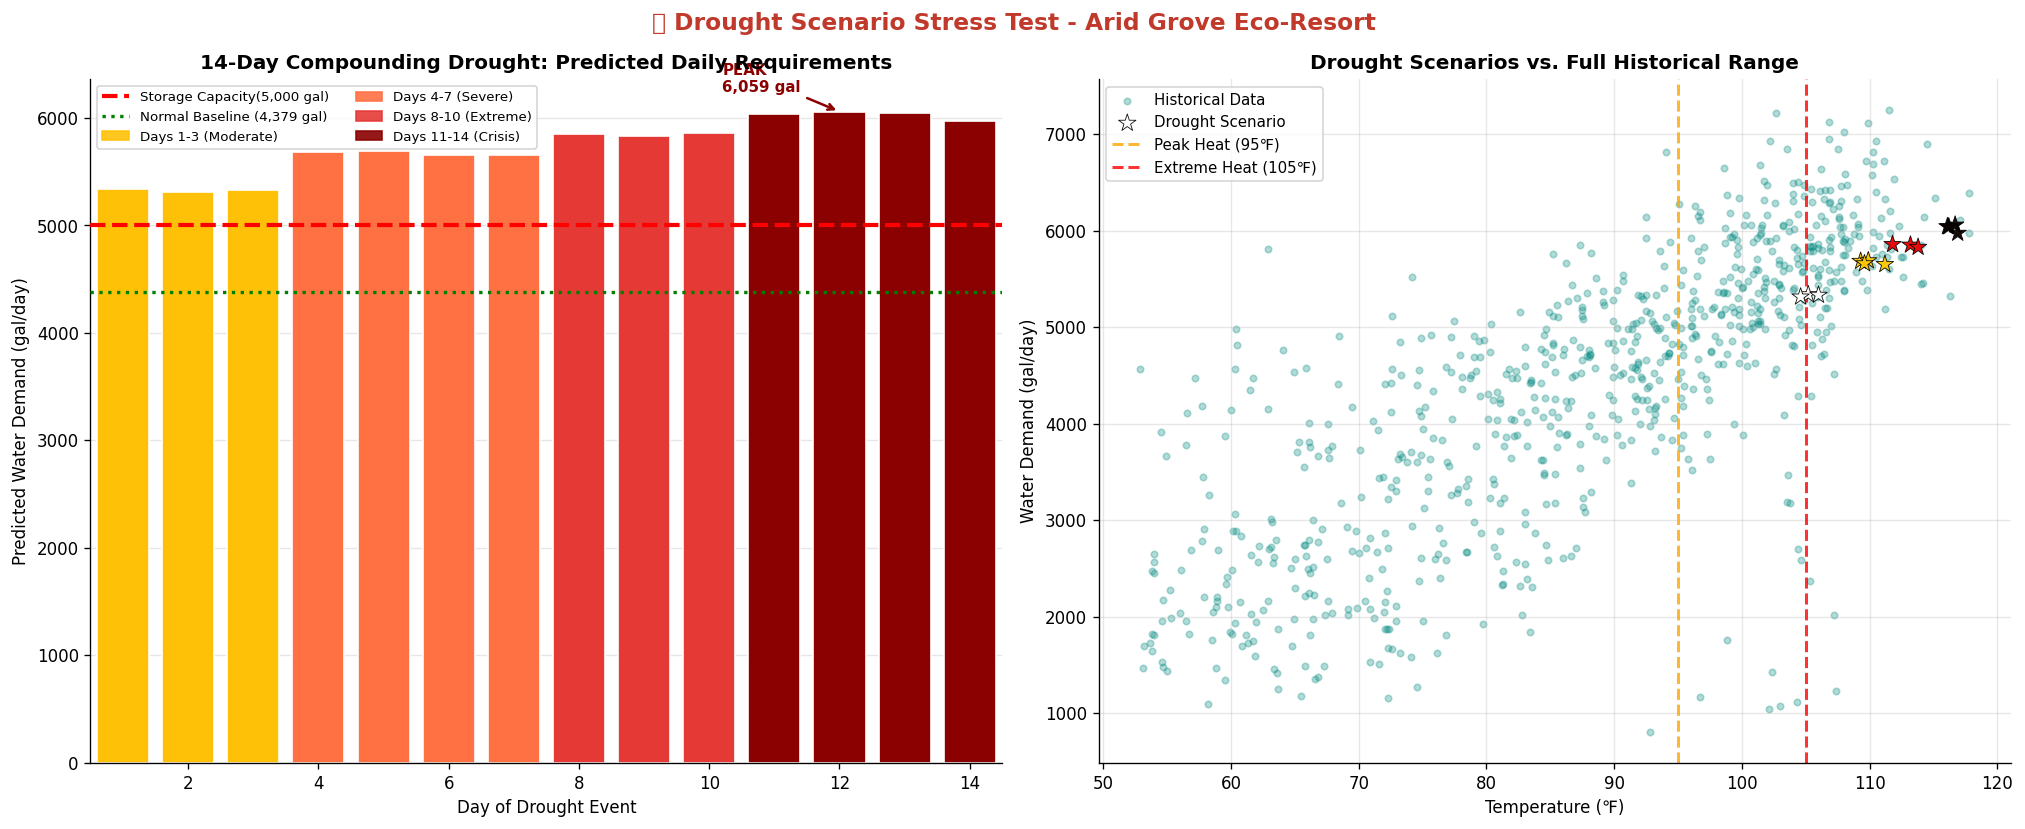

✅ Drought scenario visualization saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('🌵 Drought Scenario Stress Test - Arid Grove Eco-Resort',
            fontsize=14, fontweight='bold', color='#C0392B')

PHASE_COLORS = {
    'Days 1-3\n(Moderate)': '#FFC107',
    'Days 4-7\n(Severe)'  : '#FF7043',
    'Days 8-10\n(Extreme)': '#E53935',
    'Days 11-14\n(Crisis)': '#8B0000',
}

# -- 1. Day-by-day demand ------------------------------------------------------------
ax = axes[0]
bar_fill = [PHASE_COLORS[p] for p in drought_df['phase']]
ax.bar(drought_df['day'], drought_df['predicted_demand'],
      color=bar_fill, edgecolor='white', width=0.8, zorder=2)

ax.axhline(STORAGE_CAPACITY, color='red', lw=2.5, linestyle='--', zorder=3,
          label=f'Storage Capacity({STORAGE_CAPACITY:,.0f} gal)')
ax.axhline(BASELINE_DEMAND, color='green', lw=2, linestyle=':', zorder=3,
          label=f'Normal Baseline ({BASELINE_DEMAND:,.0f} gal)')

# Annotate peak
peak_row = drought_df.loc[drought_df['predicted_demand'].idxmax()]
ax.annotate(f"PEAK\n{peak_row['predicted_demand']:,.0f} gal",xy=(peak_row['day'], peak_row['predicted_demand']),xytext=(peak_row['day'] - 1.8, peak_row['predicted_demand'] + 180),arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),fontsize=9, fontweight='bold', color='darkred')

phase_legend = [mpatches.Patch(color=c, label=l.replace('\n', ' '), alpha=0.9)
               for l, c in PHASE_COLORS.items()]
main_legend = [ax.lines[0], ax.lines[1]]
ax.legend(handles=main_legend + phase_legend, fontsize=8, ncol=2, loc='upper left')
ax.set_xlabel('Day of Drought Event', fontsize=10)
ax.set_ylabel('Predicted Water Demand (gal/day)', fontsize=10)
ax.set_title('14-Day Compounding Drought: Predicted Daily Requirements', fontweight='bold')
ax.set_xlim(0.5, 14.5)
ax.grid(axis='y', alpha=0.3)

# -- Historical data + Drought overlay scatter ------------------------------------------------
ax = axes[1]
ax.scatter(df_feat['temp_f'], df_feat['water_demand_gal'],
          alpha=0.30, s=15, color=C['accent'], label='Historical Data', zorder=1)
sc = ax.scatter(drought_df['temp_f'], drought_df['predicted_demand'],
               c=[list(PHASE_COLORS.keys()).index(p) for p in drought_df['phase']],
               cmap='hot_r', alpha=0.95, s=120, marker='*', zorder=5,
               edgecolors='black', lw=0.5, label='Drought Scenario')
ax.axvline(PEAK_HEAT_THRESH, color='orange', lw=1.8, linestyle='--', alpha=0.8,
          label=f'Peak Heat ({PEAK_HEAT_THRESH}℉)')
ax.axvline(105, color='red', lw=1.8, linestyle='--', alpha=0.8, label='Extreme Heat (105℉)')
ax.set_xlabel('Temperature (℉)', fontsize=10)
ax.set_ylabel('Water Demand (gal/day)', fontsize=10)
ax.set_title('Drought Scenarios vs. Full Historical Range', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('drought_scenario.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Drought scenario visualization saved")

# EXECUTIVE PDF EXPORT #

In [15]:
# =====================================================================
# EXECUTIVE PDF EXPORT  –  3-Page Report
# Page 1 : Water Demand vs Temperature + Feature Correlations
# Page 2 : Model Performance Metrics + Actual vs Predicted
# Page 3 : Drought Scenario Stress Test
# =====================================================================
import datetime

with PdfPages('executive_report_aridgrove.pdf') as pdf:

    # ── HELPER: branded page header ─────────────────────────────────
    def add_header(fig, subtitle):
        fig.patch.set_facecolor(C['light'])
        fig.text(0.5, 0.97, 'ARID GROVE ECO-RESORT', ha='center',
                 fontsize=18, fontweight='bold', color=C['primary'])
        fig.text(0.5, 0.935, subtitle, ha='center',
                 fontsize=11, color=C['accent'])
        fig.text(0.5, 0.905, '─' * 110, ha='center',
                 color='lightgray', fontsize=5)
        today = datetime.date.today().strftime('%B %d, %Y')
        fig.text(0.96, 0.01, f'Confidential | Generated {today}',
                 ha='right', fontsize=7, color='gray')

    # ══════════════════════════════════════════════════════════════════
    # PAGE 1 — Water Demand vs Temperature & Key Correlations
    # ══════════════════════════════════════════════════════════════════
    fig1 = plt.figure(figsize=(11, 8.5))
    add_header(fig1, 'Predictive Water Resource Modeling — Executive Report | Page 1 of 3')
    gs1 = GridSpec(2, 2, figure=fig1,
                   top=0.88, bottom=0.08, left=0.08, right=0.96,
                   hspace=0.42, wspace=0.32)

    # 1a. Water Demand vs Temperature (the primary deliverable chart)
    ax = fig1.add_subplot(gs1[0, :])   # full-width top row
    sc = ax.scatter(df_merged['temp_f'], df_merged['water_demand_gal'],
                    c=df_merged['occupancy_rate'], cmap='YlOrRd',
                    alpha=0.45, s=14, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax, label='Occupancy Rate', shrink=0.7, pad=0.01)
    ax.axvline(PEAK_HEAT_THRESH, color=C['heat'], lw=1.8, linestyle='--', alpha=0.8,
               label=f'Peak Heat Threshold ({PEAK_HEAT_THRESH}℉)')
    ax.axvline(105, color='darkred', lw=1.5, linestyle=':', alpha=0.7,
               label='Extreme Heat (105℉)')
    # Trend line
    z = np.polyfit(df_merged['temp_f'], df_merged['water_demand_gal'], 2)
    p = np.poly1d(z)
    t_range = np.linspace(df_merged['temp_f'].min(), df_merged['temp_f'].max(), 200)
    ax.plot(t_range, p(t_range), color=C['primary'], lw=2.5, label='Quadratic trend', zorder=5)
    r_val = df_merged['water_demand_gal'].corr(df_merged['temp_f'])
    ax.set_title(f'Water Demand vs. Temperature  (r = {r_val:+.3f}, n = {len(df_merged):,} days)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Daily High Temperature (℉)', fontsize=10)
    ax.set_ylabel('Water Demand (gal/day)', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')

    # 1b. Correlation heatmap
    ax2 = fig1.add_subplot(gs1[1, 0])
    corr_cols = ['water_demand_gal', 'guests_on_property', 'occupancy_rate',
                 'temp_f', 'humidity_pct', 'et0']
    corr_labels = ['Water\nDemand', 'Guests', 'Occ.\nRate', 'Temp\n(℉)', 'Humidity\n(%)', 'ET0']
    cm = df_merged[corr_cols].corr()
    sns.heatmap(cm, ax=ax2, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                square=True, annot_kws={'size': 8},
                xticklabels=corr_labels, yticklabels=corr_labels,
                linewidths=0.4, linecolor='white', cbar=False)
    ax2.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=10)
    ax2.tick_params(labelsize=7)

    # 1c. Peak Heat vs Normal boxplot
    ax3 = fig1.add_subplot(gs1[1, 1])
    grps = [
        df_merged[df_merged['temp_f'] <  PEAK_HEAT_THRESH]['water_demand_gal'].values,
        df_merged[df_merged['temp_f'] >= PEAK_HEAT_THRESH]['water_demand_gal'].values,
    ]
    bp = ax3.boxplot(grps, labels=['Normal Days\n(< 95℉)', 'Peak Heat Days\n(≥ 95℉)'],
                     patch_artist=True, widths=0.45,
                     medianprops=dict(color='white', lw=2.5))
    bp['boxes'][0].set(facecolor=C['accent'], alpha=0.8)
    bp['boxes'][1].set(facecolor=C['heat'], alpha=0.8)
    for i, g in enumerate(grps, 1):
        ax3.text(i, np.mean(g), f'μ={np.mean(g):,.0f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax3.set_title('Demand: Normal vs Peak Heat Days', fontweight='bold', fontsize=10)
    ax3.set_ylabel('Water Demand (gal/day)', fontsize=9)

    plt.savefig('pdf_page1.png', dpi=150, bbox_inches='tight')
    pdf.savefig(fig1, bbox_inches='tight')
    plt.close(fig1)
    print("✅ Page 1 written")

    # ══════════════════════════════════════════════════════════════════
    # PAGE 2 — Model Performance Metrics
    # ══════════════════════════════════════════════════════════════════
    fig2 = plt.figure(figsize=(11, 8.5))
    add_header(fig2, 'Predictive Water Resource Modeling — Executive Report | Page 2 of 3')
    gs2 = GridSpec(2, 2, figure=fig2,
                   top=0.88, bottom=0.08, left=0.08, right=0.96,
                   hspace=0.42, wspace=0.32)

    model_names  = list(results.keys())
    bar_colors_m = [C['heat'] if m == BEST_MODEL else C['accent'] for m in model_names]

    # 2a. R² comparison
    ax = fig2.add_subplot(gs2[0, 0])
    r2_vals = [results[m]['R²'] for m in model_names]
    bars = ax.bar(model_names, r2_vals, color=bar_colors_m, alpha=0.87, edgecolor='white')
    ax.set_ylim(0, 1.12); ax.set_ylabel('R² Score')
    ax.set_title('R² Score by Model', fontweight='bold')
    ax.axhline(0.90, color='gray', lw=1.3, linestyle='--', alpha=0.6, label='0.90 benchmark')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)

    # 2b. MAE & RMSE
    ax = fig2.add_subplot(gs2[0, 1])
    x = np.arange(len(model_names)); w = 0.35
    b1 = ax.bar(x - w/2, [results[m]['MAE']  for m in model_names], w,
                label='MAE',  color=C['accent'], alpha=0.85)
    b2 = ax.bar(x + w/2, [results[m]['RMSE'] for m in model_names], w,
                label='RMSE', color=C['warm'],   alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=8)
    ax.set_ylabel('Error (gallons)'); ax.set_title('MAE & RMSE by Model', fontweight='bold')
    ax.legend(fontsize=8)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7)

    # 2c. Actual vs Predicted (best model)
    ax = fig2.add_subplot(gs2[1, 0])
    y_pred_best = predictions[BEST_MODEL]
    ax.scatter(y_test.values, y_pred_best, alpha=0.40, s=14,
               color=C['primary'], label='Test predictions', zorder=2)
    lims = [min(y.min(), y_pred_best.min()), max(y.max(), y_pred_best.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit', zorder=3)
    ax.fill_between(lims, [l * 0.90 for l in lims], [l * 1.10 for l in lims],
                    alpha=0.07, color='red', label='±10% band')
    ax.set_xlabel('Actual Water Demand (gal)', fontsize=9)
    ax.set_ylabel('Predicted (gal)', fontsize=9)
    ax.set_title(f'Actual vs Predicted — {BEST_MODEL}\nR² = {results[BEST_MODEL]["R²"]:.4f}',
                 fontweight='bold')
    ax.legend(fontsize=8)

    # 2d. Residual plot
    ax = fig2.add_subplot(gs2[1, 1])
    residuals = y_test.values - y_pred_best
    ax.scatter(y_pred_best, residuals, alpha=0.35, s=14,
               color=C['accent'], edgecolors='none')
    ax.axhline(0,  color='red',    lw=2,   linestyle='--')
    ax.axhline(+results[BEST_MODEL]['MAE'], color='orange', lw=1.3,
               linestyle=':', alpha=0.8, label='+MAE')
    ax.axhline(-results[BEST_MODEL]['MAE'], color='orange', lw=1.3,
               linestyle=':', alpha=0.8, label='−MAE')
    ax.set_xlabel('Predicted Value (gal)', fontsize=9)
    ax.set_ylabel('Residual (gal)', fontsize=9)
    ax.set_title(f'Residual Plot — {BEST_MODEL}', fontweight='bold')
    ax.legend(fontsize=8)

    plt.savefig('pdf_page2.png', dpi=150, bbox_inches='tight')
    pdf.savefig(fig2, bbox_inches='tight')
    plt.close(fig2)
    print("✅ Page 2 written")

    # ══════════════════════════════════════════════════════════════════
    # PAGE 3 — Drought Scenario Stress Test
    # ══════════════════════════════════════════════════════════════════
    fig3 = plt.figure(figsize=(11, 8.5))
    add_header(fig3, 'Predictive Water Resource Modeling — Executive Report | Page 3 of 3')
    gs3 = GridSpec(2, 2, figure=fig3,
                   top=0.88, bottom=0.08, left=0.08, right=0.96,
                   hspace=0.42, wspace=0.32)

    PHASE_COLORS = {
        'Days 1-3\n(Moderate)': '#FFC107',
        'Days 4-7\n(Severe)'  : '#FF7043',
        'Days 8-10\n(Extreme)': '#E53935',
        'Days 11-14\n(Crisis)': '#8B0000',
    }

    # 3a. Day-by-day bar chart (full width)
    ax = fig3.add_subplot(gs3[0, :])
    bar_fill = [PHASE_COLORS[p] for p in drought_df['phase']]
    ax.bar(drought_df['day'], drought_df['predicted_demand'],
           color=bar_fill, edgecolor='white', width=0.8, zorder=2)
    ax.axhline(STORAGE_CAPACITY, color='red', lw=2.2, linestyle='--', zorder=3,
               label=f'Storage Capacity ({STORAGE_CAPACITY:,.0f} gal)')
    ax.axhline(BASELINE_DEMAND, color='green', lw=1.8, linestyle=':', zorder=3,
               label=f'Normal Baseline ({BASELINE_DEMAND:,.0f} gal)')
    peak_row = drought_df.loc[drought_df['predicted_demand'].idxmax()]
    ax.annotate(
        f"PEAK\n{peak_row['predicted_demand']:,.0f} gal",
        xy=(peak_row['day'], peak_row['predicted_demand']),
        xytext=(peak_row['day'] - 2.2, peak_row['predicted_demand'] + 200),
        arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
        fontsize=9, fontweight='bold', color='darkred'
    )
    phase_patches = [mpatches.Patch(color=c, label=l.replace('\n', ' '), alpha=0.9)
                     for l, c in PHASE_COLORS.items()]
    ax.legend(handles=[ax.lines[0], ax.lines[1]] + phase_patches,
              fontsize=8, ncol=3, loc='upper left')
    ax.set_xlabel('Day of Drought Event', fontsize=10)
    ax.set_ylabel('Predicted Water Demand (gal/day)', fontsize=10)
    ax.set_title('14-Day Compounding Drought: Predicted Daily Water Requirements',
                 fontweight='bold', fontsize=11, color='#C0392B')
    ax.set_xlim(0.5, 14.5)
    ax.grid(axis='y', alpha=0.3)

    # 3b. Drought vs Historical scatter
    ax = fig3.add_subplot(gs3[1, 0])
    ax.scatter(df_feat['temp_f'], df_feat['water_demand_gal'],
               alpha=0.25, s=12, color=C['accent'], label='Historical Data', zorder=1)
    ax.scatter(drought_df['temp_f'], drought_df['predicted_demand'],
               c=[list(PHASE_COLORS.keys()).index(p) for p in drought_df['phase']],
               cmap='hot_r', alpha=0.95, s=110, marker='*', zorder=5,
               edgecolors='black', lw=0.4, label='Drought Scenario')
    ax.axvline(PEAK_HEAT_THRESH, color='orange', lw=1.5, linestyle='--', alpha=0.8,
               label=f'Peak Heat ({PEAK_HEAT_THRESH}℉)')
    ax.axvline(105, color='red', lw=1.5, linestyle='--', alpha=0.8, label='Extreme (105℉)')
    ax.set_xlabel('Temperature (℉)', fontsize=9)
    ax.set_ylabel('Water Demand (gal/day)', fontsize=9)
    ax.set_title('Drought Scenarios vs. Historical Range', fontweight='bold')
    ax.legend(fontsize=7)

    # 3c. Phase summary table
    ax = fig3.add_subplot(gs3[1, 1])
    ax.axis('off')
    phase_summary = drought_df.groupby('phase').agg(
        Temp_F    = ('temp_f',             'mean'),
        Avg_Demand= ('predicted_demand',   'mean'),
        Peak_Demand=('predicted_demand',   'max'),
    ).reset_index()
    phase_summary.columns = ['Phase', 'Avg Temp (℉)', 'Avg Demand (gal)', 'Peak Demand (gal)']
    # Clean phase labels for display
    phase_summary['Phase'] = phase_summary['Phase'].str.replace('\n', ' ')
    for col in ['Avg Demand (gal)', 'Peak Demand (gal)']:
        phase_summary[col] = phase_summary[col].apply(lambda v: f'{v:,.0f}')
    phase_summary['Avg Temp (℉)'] = phase_summary['Avg Temp (℉)'].apply(lambda v: f'{v:.1f}')
    pct_inc = (drought_df['predicted_demand'].max() / BASELINE_DEMAND - 1) * 100
    tbl = ax.table(
        cellText  = phase_summary.values,
        colLabels = phase_summary.columns,
        cellLoc   = 'center', loc='center',
        bbox      = [0, 0.25, 1.0, 0.65]
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(8)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor(C['primary']); cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#EAF4F4')
    ax.text(0.5, 0.92, 'Drought Phase Summary', ha='center', va='top',
            transform=ax.transAxes, fontsize=10, fontweight='bold')
    ax.text(0.5, 0.18,
            f'Baseline: {BASELINE_DEMAND:,.0f} gal/day  |  '
            f'Peak: {drought_df["predicted_demand"].max():,.0f} gal/day  |  '
            f'Increase: +{pct_inc:.1f}%',
            ha='center', va='top', transform=ax.transAxes, fontsize=8, color=C['heat'])
    exceed = (drought_df['predicted_demand'] > STORAGE_CAPACITY).sum()
    ax.text(0.5, 0.08,
            f'⚠️  {exceed} of 14 days exceed onsite storage capacity ({STORAGE_CAPACITY:,} gal)',
            ha='center', va='top', transform=ax.transAxes, fontsize=8,
            color='darkred', fontweight='bold')

    pdf.savefig(fig3, bbox_inches='tight')
    plt.close(fig3)
    print("✅ Page 3 written")

    # PDF metadata
    d = pdf.infodict()
    d['Title']   = 'Arid Grove Eco-Resort – Predictive Water Resource Modeling'
    d['Author']  = 'Arid Grove Operations Analytics'
    d['Subject'] = 'Executive Report: Water Demand Forecasting'

print("\n📄 Executive PDF saved → executive_report_aridgrove.pdf")


✅ Page 1 written
✅ Page 2 written
✅ Page 3 written

📄 Executive PDF saved → executive_report_aridgrove.pdf


In [16]:
# ── Final summary printout ─────────────────────────────────────────────────
print("=" * 62)
print(" ✅  ARID GROVE WATER RESOURCE MODEL — COMPLETE")
print("=" * 62)
print(f"  Dataset          : {len(df_feat):,} daily records ({df_feat['date'].min().year}–{df_feat['date'].max().year})")
print(f"  Features used    : {len(FEATURE_COLS)}")
print(f"  Best model       : {BEST_MODEL}")
print(f"  R²               : {results[BEST_MODEL]['R²']:.4f}")
print(f"  MAE              : {results[BEST_MODEL]['MAE']:,.1f} gal/day")
print(f"  MAPE             : {results[BEST_MODEL]['MAPE']:.2f}%")
print()
print(f"  Peak Heat Days   : {df_feat['peak_heat_day'].sum():,}  ({df_feat['peak_heat_day'].mean()*100:.1f}%)")
print(f"  High-Density Days: {df_feat['high_density'].sum():,}  ({df_feat['high_density'].mean()*100:.1f}%)")
print()
pct = (drought_df['predicted_demand'].max() / BASELINE_DEMAND - 1) * 100
print(f"  Drought peak demand  : {drought_df['predicted_demand'].max():,.0f} gal/day (+{pct:.1f}%)")
exceed = (drought_df['predicted_demand'] > STORAGE_CAPACITY).sum()
print(f"  Days over capacity   : {exceed} of 14")
print()
print("  Deliverables:")
print("    📓 aridgrove-waterresourcemodel.ipynb  (this notebook)")
print("    📄 executive_report_aridgrove.pdf      (3-page executive report)")



 ✅  ARID GROVE WATER RESOURCE MODEL — COMPLETE
  Dataset          : 806 daily records (2015–2017)
  Features used    : 22
  Best model       : XGBoost
  R²               : 0.8391
  MAE              : 384.0 gal/day
  MAPE             : 9.27%

  Peak Heat Days   : 331  (41.1%)
  High-Density Days: 593  (73.6%)

  Drought peak demand  : 6,059 gal/day (+38.4%)
  Days over capacity   : 14 of 14

  Deliverables:
    📓 aridgrove-waterresourcemodel.ipynb  (this notebook)
    📄 executive_report_aridgrove.pdf      (3-page executive report)
